**RELATORIO 1 : Resolução Numérica de Equações Algébricas e Transcendentes**

---









**BIBLIOTECAS USADAS:**

In [ ]:
import math
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

Dados de entrada e Métodos usados

In [ ]:
# def f(x): return x**2 - 4
# a = 1.0
# b = 3.0
# prec = 0.001

def exec_bisseccao(f, a, b, prec):

    if f(a) * f(b) >= 0:
        raise ValueError('Bissecção falhou: f(a) e f(b) devem ter sinais opostos.')

    # Caso o intervalo já seja menor que a precisão
    if (b - a) < prec:
        return (a + b) / 2

    k = 1
    M = f(a)

    while True:
        x = (a + b) / 2
        valor_f_x = f(x)

        if (M * valor_f_x) > 0:
            a = x
            if (b - a) < prec:
                return x
        else:
            b = x
            if (b - a) < prec:
                return x

        k = k + 1
        if k > 1000:
            break

    return x


# resultado = exec_bisseccao(f, a, b, prec)
# print(f"Bissecção - Raiz: {resultado}")

#GRÁFICO
 #x_plot = np.linspace(a - 1, b + 1, 400)
 #y_plot = f(x_plot)
 #plt.figure(figsize=(10, 6))
 #plt.plot(x_plot, y_plot, label='f(x)', color='pink', linewidth=2)
 #plt.axhline(0, color='black', linestyle='--', linewidth=1)
 #plt.plot(resultado, f(resultado), 'ro', label=f'Raiz: {resultado:.4f}')
 #plt.title('Método da Bissecção - Visualização')
 #plt.grid(True, alpha=0.3)
 #plt.legend()
 #plt.show()

In [ ]:
# Método da Falsa Posição

# 1. Definição da Função e Dados
#def f(x):
 #   return x**3 - 9*x + 3

#a = 0.0
#b = 1.0
#prec1, prec2 = 0.001, 0.001

def executar_falsa_posicao(f, a, b, prec1, prec2):
    # para listar as iteracoes
    historico_x = []

    # Verificações iniciais
    if abs(b - a) < prec1: return (a + b) / 2, [(a + b) / 2]
    if abs(f(a)) < prec2: return a, [a]
    if abs(f(b)) < prec2: return b, [b]

    k = 1
    M = f(a)

    while True:
        fa, fb = f(a), f(b)

        if (fb - fa) == 0: break
        x = (a * fb - b * fa) / (fb - fa)
        historico_x.append(x)

        fx = f(x)

        if abs(fx) < prec2:
            return x, historico_x

        if (M * fx) > 0:
            a = x
        else:
            b = x

        if abs(b - a) < prec1:
            return x, historico_x

        k = k + 1
        if k > 1000: break

    return x, historico_x

# 2. EXECUÇÃO (Sem espaços no início para evitar IndentationError)
#raiz, pontos = executar_falsa_posicao(f, a, b, prec1, prec2)
#print(f"Raiz encontrada: {raiz:.6f}")

# 3. GRÁFICO (Ativado para rodar junto)
#x_curva = np.linspace(a - 0.5, b + 0.5, 400)
#y_curva = f(x_curva)

#plt.figure(figsize=(10, 6))
#plt.plot(x_curva, y_curva, label='f(x)', color='pink', lw=2)
#plt.plot([a, b], [f(a), f(b)], 'g--', label='Corda (Falsa Posição)')
#plt.axhline(0, color='purple', lw=1)
#plt.plot(raiz, f(raiz), 'ro', label=f'Raiz: {raiz:.4f}')
#plt.scatter(pontos, [f(p) for p in pontos], color='orange', s=30, label='Iterações', zorder=5)

#plt.title('Método da Falsa Posição - Visualização')
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.show()

In [ ]:
#secante

# Exemplo de uso
#def f(x):
 #   return x**3 - 9*x + 3

#x0_ini = 0.0
#x1_ini = 0.5
#prec1 = 0.0001
#prec2 = 0.0001

def metodo_secante_ruggiero(f, x0, x1, prec1, prec2):
    # Criando a lista para armazenar o caminho (para o gráfico)
    historico_x = [x0, x1]

    # PASSO 2 e 3
    if abs(f(x0)) < prec1: return x0, [x0]
    if abs(f(x1)) < prec1 or abs(x1 - x0) < prec2: return x1, [x0, x1]

    print(f"\n{'k':<5} | {'x0':<10} | {'x1':<10} | {'x2':<10} | {'f(x2)':<10}")
    print("-" * 55)

    k = 1
    while True:
        # PASSO 5: Fórmula da Secante
        f_x0 = f(x0)
        f_x1 = f(x1)

        if (f_x1 - f_x0) == 0: break

        # x2 é a interseção da reta que passa por (x0, f(x0)) e (x1, f(x1))
        x2 = x1 - (f_x1 * (x1 - x0)) / (f_x1 - f_x0)
        f_x2 = f(x2)
        historico_x.append(x2)

        print(f"{k:<5} | {x0:<10.5f} | {x1:<10.5f} | {x2:<10.5f} | {f_x2:<10.5f}")

        # PASSO 6: Critérios de parada
        if abs(f_x2) < prec1 or abs(x2 - x1) < prec2:
            return x2, historico_x

        # PASSO 7 e 8
        x0 = x1
        x1 = x2
        k = k + 1
        if k > 100:
            break

    return x1, historico_x

# Execução
#raiz, pontos = metodo_secante_ruggiero(f, x0_ini, x1_ini, prec1, prec2)
#print("-" * 55)
#print(f"Raiz encontrada pela Secante: {raiz:.6f}")

# GRÁFICO

# Criando dados para a curva
#x_curva = np.linspace(min(pontos) - 0.5, max(pontos) + 0.5, 400)
#y_curva = f(x_curva)

#plt.figure(figsize=(10, 6))

#  curva da função
#plt.plot(x_curva, y_curva, label='f(x)', color='pink', lw=2)

# linha secante entre os dois pontos iniciais
#plt.plot([pontos[0], pontos[1]], [f(pontos[0]), f(pontos[1])], 'g--', label='Reta Secante Inicial')

# eixos
#plt.axhline(0, color='purple', lw=1)
#plt.axvline(0, color='blue', lw=1)

# 4. Destaca a raiz encontrada
#plt.plot(raiz, f(raiz), 'ro', label=f'Raiz encontrada: {raiz:.4f}')

# 5. Adiciona os pontos intermediários (os chutes do algoritmo)
#plt.scatter(pontos, [f(p) for p in pontos], color='orange', s=30, zorder=5, label='Iterações (x)')

#plt.title('Método da Secante - Visualização')
#plt.xlabel('x')
#plt.ylabel('f(x)')
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.show()

In [ ]:
# Newton Raphson
#encontrar raízes de uma função real f(x)=0,aproximando a função por sua reta tangente em cada ponto
#precisao = 1e-6 = 10^-6 =  0.000001

import sympy as sp

def newton_Raphson(f_expr, x0, precisao = 1e-6 , max_iter=100):

  #calcula derivada automaticamente
    x = sp.symbols('x')
    f = sp.sympify(f_expr)
    derivada_f = sp.diff(f, x)

    f_num = sp.lambdify(x, f)
    derivada_f_num = sp.lambdify(x, derivada_f)

    xn = float(x0)
    iteracoes = 0

    for i in range(max_iter):
        iteracoes = i + 1

        #Calcula o valor da função no ponto atual para verificar a proximidade da raiz.
        f_val = f_num(xn)

        if abs(f_val) < precisao:
            break

        df_val = derivada_f_num(xn)

        if df_val == 0:
            raise ValueError("Derivada zero encontrada. Método não pode continuar.")

        xn -= f_val/df_val

    def exibir_resultados(num): #formataçao dos resultados
        num_str = "{0:.4f}".format(num)
        if '.' in num_str:
            num_str = num_str.rstrip('0').rstrip('.') if num_str.endswith('0') else num_str
        return num_str

    raiz_formatada = exibir_resultados(xn)
    valor_formatado = exibir_resultados(float(f_num(xn)))

    print(f"Raiz encontrada: {raiz_formatada}")
    print(f"Valor na raiz: f({raiz_formatada}) = {valor_formatado}")
    print(f"Número de iterações: {iteracoes}/{max_iter}")

    return xn

In [ ]:
#grafico

def plot_grafico(a, b, xlabel='x', ylabel='f(x)', title='txt', raiz=None,ite=0,raiz_exat=0):
    plt.plot(a, b)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.axhline(0, color='red', linestyle='--')  # Linha do eixo x (y=0)

    # Adiciona um marcador na raiz, se fornecida
    if raiz is not None:
         idx = (abs(x - raiz)).argmin()

    if raiz_exat != 0:
         plt.scatter(raiz, y[idx], color='pink', label=f'Raiz ≈ {raiz:.4f} em {ite} iterações')
         plt.legend()
    else:
         plt.scatter(raiz, y[idx], color='purple', label=f'Raiz ≈ {raiz:.4f} em {ite} iterações')
         plt.legend()




# **Exercícios**

1. A equação de Kepler, usada para determinar órbitas de satélites é dada por:
M = x – E sen(x)
Dado que E = 0.2 e M = 0.5, obtenha a raiz da equação de Kepler usando o
Método da Bissecção. Considere a = 0.0, b = 2.0 e  = 10

In [ ]:
#compile os metodos antes de compilar a questao
import numpy as np

def f_kepler(x):
    E = 0.2
    M = 0.5
    # f(x) = x - E*sen(x) - M
    return x - E * np.sin(x) - M

raiz_kepler = exec_bisseccao(f_kepler, 0.0, 2.0, 0.001)

print(f"Questão 1 (Kepler) -> Raiz encontrada: {raiz_kepler:.4f}")

Questão 1 (Kepler) -> Raiz encontrada: 0.6162


2. Uma das soluções para os resíduos de material nuclear é colocá-los em barris especiais que serão mais tarde depositados no fundo do oceano. Se os
recipientes permanecerem intactos, a contaminação do ambiente ao redor é
mínima. Resolvendo as equações de movimento para os barris à medida que eles descem na água, chega-se à seguinte relação entre a velocidade de impacto, v, e a profundidade da água, D:

D = 1
𝑘2g [𝑊 (𝑊 − 𝐵) ln(1 + 𝑘𝑣
𝑊−𝐵) − 𝑊𝑘𝑣]
em que W é o peso dos barris, B é a sua flutuabilidade, g é a constante
gravitacional e k é o coeficiente de atrito. A flutuabilidade dos barris pode ser
determinada através do seu volume, sendo igual a B = 470. O coeficiente de
atrito é determinado experimentalmente e é dado por k = 0.08. A constante
gravitacional é g = 32 e o peso dos barris W = 527.
a) Determine a velocidade de impacto v usando o Método da Falsa Posição,
quando os barris são lançados numa zona cuja profundidade é D=−300. Utilize
como aproximações iniciais v1 = 40 e v2 = 45, e no critério de parada ε1 = ε2 = 0.05
Utilize nos cálculos 4 casas decimais truncadas.

In [ ]:
#compile os metodos antes de compilar a questao
import math

def truncar(valor, casas=4):
    pos = 10**casas
    return math.trunc(valor * pos) / pos

def f2(v):
    W, B, k, g = 527, 470, 0.08, 32
    D_alvo = -300
    W_B = W - B # 57

    # Calculo da Equação D
    c1 = truncar(1 / (k**2 * g))

    termo_v = truncar(k * v)
    razao = truncar(termo_v / W_B)
    log_val = truncar(math.log(1 + razao))

    parte1 = truncar(W * W_B * log_val)
    parte2 = truncar(W * termo_v)

    D_calculado = truncar(c1 * (parte1 - parte2))

    # f(v) = D_calculado - (-300) -> D_calculado + 300
    return truncar(D_calculado - D_alvo)

v_res, historico = executar_falsa_posicao(f2, 40.0, 45.0, 0.05, 0.05)

print(f"a) Velocidade de impacto encontrada: v = {v_res}")
print(f"b) Risco de contaminação? {'SIM' if v_res > 40 else 'NÃO'}. v = {v_res} > 40.")


a) Velocidade de impacto encontrada: v = 44.98320699141111
b) Risco de contaminação? SIM. v = 44.98320699141111 > 40.


2. b) Resposta:
 sim,  haverá risco de contaminação. Nas condições ditas, a velocidade de impacto calculada foi de aproximadamente $44.9832$ e isso excede o limite de segurança , que é 40. O que ocasionaria no vazamento de resíduos nucleares no mar.

3. Em problemas de fluxo em tubulações, é frequente precisar resolver a equação:
c5 D5 + c1 D + c0 = 0. Se c5 = 1000, c1 = −3 e c0 = 9.04, determine a raiz usando o
Método de Newton-Raphson/Tangente. Considere x0 = -0.5 e  = 10^-3

In [ ]:
#compile os metodos antes de compilar a questao
import sympy as sp

expressao_tubulacao = "1000*x**5 - 3*x + 9.04"
chute_inicial = -0.5
eps = 10**-3  #0.001

def newton_Raphson(f_expr, x0, precisao=0.001, max_iter=100):

    x = sp.symbols('x')
    f_sym = sp.sympify(f_expr)
    derivada_f = sp.diff(f_sym, x)

    f_num = sp.lambdify(x, f_sym)
    df_num = sp.lambdify(x, derivada_f)

    xn = float(x0)
    iteracoes = 0

    print(f"{'k':<5} | {'xn':<10} | {'f(xn)':<10} | {'f_derivada':<10}")
    print("-" * 50)

    #calculo Newton-Raphson
    for i in range(max_iter):
        iteracoes = i + 1
        f_val = f_num(xn)
        df_val = df_num(xn)

        print(f"{i:<5} | {xn:<10.6f} | {f_val:<10.6f} | {df_val:<10.6f}")

        if abs(f_val) < precisao:
            break

        if df_val == 0:
            raise ValueError("Derivada zero encontrada.")

        xn -= f_val / df_val

    print("-" * 50)
    print(f"Raiz encontrada: {xn:.6f}")
    print(f"Número de iterações: {iteracoes}")

    return xn

raiz_final = newton_Raphson(expressao_tubulacao, chute_inicial, eps)

k     | xn         | f(xn)      | f_derivada
--------------------------------------------------
0     | -0.500000  | -20.710000 | 309.500000
1     | -0.433086  | -4.896668  | 172.899687
2     | -0.404765  | -0.610299  | 131.208734
3     | -0.400113  | -0.014183  | 125.145214
4     | -0.400000  | -0.000008  | 125.000084
--------------------------------------------------
Raiz encontrada: -0.400000
Número de iterações: 5


Explicação:
 o codigo calcula o valor da função e da inclinação da reta tangente no ponto xn​. Onde essa tangente cruza o eixo x é o "chute" (xn+1​). Como visto em sala de aula.
algo legal é que esse metodo é bom para problemas de engenharia, como este,  porque converge quadraticamente e se usasse-mos outro metodo, como bisseção, teria bem mais interações.

4. Em engenharia ambiental, a equação que se segue pode ser usada para calcular o nível de oxigênio, c, existente num rio a jusante de um local de descarga de esgoto,
c = 10 − 15(e−0.1x − e−0.5x)
em que x representa a distância a partir do local de descarga. Usando o Método da Secante, determine o local (a partir da descarga) em que o nível de oxigênio atinge o valor 4. Considere [-1.0,1.0] e  = 10^-3

Sugestão: Sabe-se que o referido local se encontra, no máximo, a 5 km a jusante do local de descarga.

A primeira vez que fiz a distancia foi 1.5798(usei os chutes iniciais: -1.0 e 1.0,), refiz ao notar a sugestão de km da "jusante" e pesquisando vi que era distancia positiva, se colocar:

$opcao_a = 2.00$

$opcao_b = 5.00$

a distancia se torna 1.5800

In [ ]:
#compile os metodos antes de compilar a questao
import numpy as np

# Para encontrar onde c = 4, subtraímos 4 da função original.
# Assim, busca a raiz (zero) da função f(x).

def f4(x):

    # Simplificado: 6 - 15 * (e^-0.1x - e^-0.5x)
    return 6 - 15 * (np.exp(-0.1 * x) - np.exp(-0.5 * x))

def metodo_secante(x0, x1, prec=0.001, max_iter=100):

    for k in range(1, max_iter + 1):
        # Calcula ordenadas (y) para pontos atuais
        fx0 = f4(x0)
        fx1 = f4(x1)
        if (fx1 - fx0) == 0:
            break

        # x2 é a raiz da reta que passa por (x0, f(x0)) e (x1, f(x1)). O resultado da primeira conta/novo ponto que a reta achou
        x2 = x1 - (fx1 * (x1 - x0)) / (fx1 - fx0)

        fx2 = f4(x2)

        # Critério de Parada
        if abs(fx2) < prec or abs(x2 - x1) < prec:
            return x2, k

        # O ponto antigo (x0) é descartado, o atual (x1) vira o antigo,
        # e o novo ponto (x2) vira o atual.
        x0 = x1
        x1 = x2
    return x1, max_iter

opcao_a = -1.0
opcao_b = 1.0
epsilon = 0.001 # 10^-3

raiz, it = metodo_secante(opcao_a, opcao_b, epsilon)
print(f"Distância encontrada: {raiz:.4f} km")
print(f"Iterações realizadas: {it}")

Distância encontrada: 1.5798 km
Iterações realizadas: 4


5. O polinômio de quarto grau f (x) = 230x4 + 18x3 + 9x2 - 221x - 9, tem dois zeros reais, um em [-1, 0] e outro em [0, 1]. Tente encontrar a aproximação desses
zeros com a precisão de 10-6, utilizando o
a) Método da Falsa Posição
b) Método da Secante
c) Plote um gráfico para explicar a diferença entre os resultados obtidos pelos Métodos da Falsa Posição e da Secante.
Observação: Utilize as extremidades de cada intervalo como aproximações
iniciais em (a) e (b).

Intervalo    | Método          | Raiz       | Iterações
-------------------------------------------------------
(-1, 0)      | Falsa Posição | -0.040659  | 101
             | Secante       | -0.040659  | 4
(0, 1)       | Falsa Posição | 0.962398   | 10
             | Secante       | -0.040659  | 11


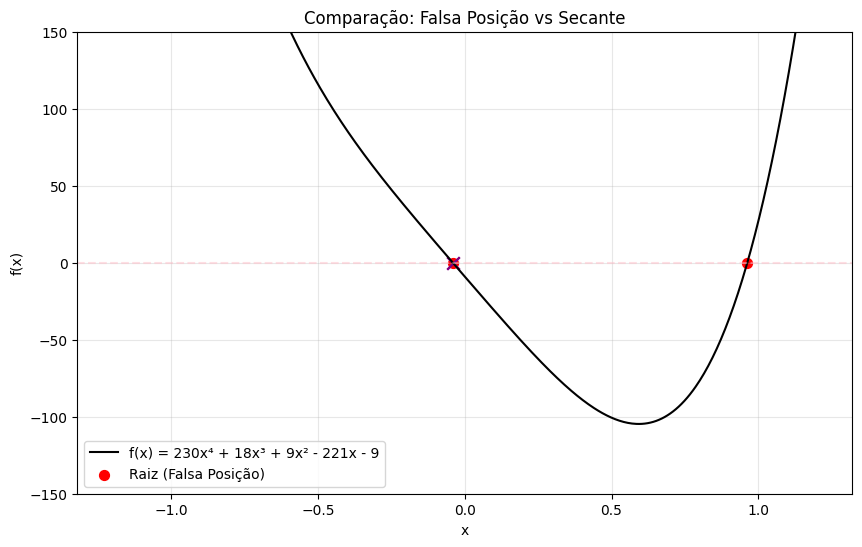

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f5(x):
    return 230*x**4 + 18*x**3 + 9*x**2 - 221*x - 9

def falsa_posicao(a, b, prec):

    k = 0
    while abs(f5(a)) > prec and abs(b - a) > prec:
        k += 1
        fa, fb = f5(a), f5(b)
        # Intersecção da corda com o eixo x
        x = (a * fb - b * fa) / (fb - fa)

        if f5(a) * f5(x) > 0:
            a = x
        else:
            b = x
        if k > 100: break
    return x, k

def secante(x0, x1, prec):

    k = 0
    while abs(f5(x1)) > prec:
        k += 1
        fx0, fx1 = f5(x0), f5(x1)
        x2 = x1 - (fx1 * (x1 - x0)) / (fx1 - fx0)
        x0, x1 = x1, x2
        if k > 100: break
    return x1, k

# calculos
precisao = 1e-6
intervalos = [(-1, 0), (0, 1)]

print(f"{'Intervalo':<12} | {'Método':<15} | {'Raiz':<10} | {'Iterações'}")
print("-" * 55)

resultados = []

for inter in intervalos:
    r_fp, k_fp = falsa_posicao(inter[0], inter[1], precisao)
    r_sec, k_sec = secante(inter[0], inter[1], precisao)

    print(f"{str(inter):<12} | Falsa Posição | {r_fp:<10.6f} | {k_fp}")
    print(f"{'':<12} | Secante       | {r_sec:<10.6f} | {k_sec}")
    resultados.append((r_fp, r_sec))

 # grafico: precisei fazer aqui

x_plot = np.linspace(-1.2, 1.2, 500)
y_plot = f5(x_plot)
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='f(x) = 230x⁴ + 18x³ + 9x² - 221x - 9', color='black', lw=1.5)
plt.axhline(0, color='pink', linestyle='--', alpha=0.5) # Eixo zero

for r_fp, r_sec in resultados:
    plt.scatter(r_fp, f5(r_fp), color='red', s=50, label='Raiz (Falsa Posição)' if r_fp > 0 else "")
    plt.scatter(r_sec, f5(r_sec), color='purple', marker='x', s=80, label='Raiz (Secante)' if r_sec > 0 else "")


plt.title("Comparação: Falsa Posição vs Secante")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-150, 150)
plt.show()

Explicação:

O Método da Falsa Posição é um método fechado e mantem raiz entre os pontos a e b .O Problema ocorre quando a curva é muito acentuada, como esse polinômio de 4º grau,se a curva é muito "convexa" perto de uma extremidade, a reta secante sempre corta o eixo $x$ muito perto de um dos limites. Ou seja, não achou raiz. Mas, no caso de [0,1], a falsa posição acertou, achando 0.962398 ,pois ela é obrigada a ficar presa dentro do intervalo $[0, 1]$.

Já a Secante , embora no primeiro caso, ela tenha sido melhor, no seguinte ela achou $-0.0406$, em vez de ir para a direita (em direção ao $0.96$), a inclinação da reta "empurrou" o próximo chute para a esquerda do  que é negativo e proximo de zero, pois ela ignora os intervalos/limites e foca mais na inclinação da reta. Chegando a conclusão que a inclinação da reta secante entre as extremidades $0$ e $1$ apontava para a região negativa do eixo $x$

no grafico: Cor Roxa (Secante)"saltou" direto para o ponto onde a curva cruza o eixo x, perto de zero.

Por fim, o método da Secante é mais rápido/eficiente, mas se precisar localizar uma raiz específica dentro de um intervalo determinado,  o método da Falsa Posição é mais confiável.